<a href="https://colab.research.google.com/github/lisciu24/MIO-fuzzy-logic/blob/main/MIO_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/Shareddrives/MIO-fuzzy-logic/"

Mounted at /content/drive


In [8]:
pip install ucimlrepo

In [9]:
import os
import pandas as pd
FILE_NAME = "winequality-red.csv"
full_file_path = os.path.join(DRIVE_PATH, FILE_NAME)

df = pd.read_csv(full_file_path, sep=';')

X = df.drop(columns=['quality'])
y = df[['quality']]

print("Rozmiar wczytanej macierzy cech X:", X.shape)
print("Rozmiar wektora wyjściowego y:", y.shape)
print("\nPierwsze 3 wiersze cech:")
print(X.head(3))

Rozmiar wczytanej macierzy cech X: (1599, 11)
Rozmiar wektora wyjściowego y: (1599, 1)

Pierwsze 3 wiersze cech:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  
0      9.4  
1      9.8  
2      9.8  


In [10]:
print(X.describe())
print(y.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [11]:
import pandas as pd

full_data = pd.concat([X, y], axis=1)

correlations = full_data.corr()['quality'].sort_values(ascending=False)
print("Korelacja cech z jakością wina:")
print(correlations)

Korelacja cech z jakością wina:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [12]:
!pip install scikit-fuzzy pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 13.8 MB/s eta 0:00:00


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

wybrane_cechy = ['alcohol', 'volatile acidity', 'sulphates']
X_reduced = X[wybrane_cechy]
X_reduced_min = dict()
X_reduced_max = dict()

for col in wybrane_cechy:
    min_val = X_reduced[col].min()
    max_val = X_reduced[col].max()
    X_reduced_min[col] = min_val
    X_reduced_max[col] = max_val
    print(f"Zmienna '{col}': zakres od {min_val} do {max_val}")

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

Zmienna 'alcohol': zakres od 8.4 do 14.9
Zmienna 'volatile acidity': zakres od 0.12 do 1.58
Zmienna 'sulphates': zakres od 0.33 do 2.0


In [14]:
#Zakresy

bounds = {
    'alc': (df['alcohol'].min(), df['alcohol'].max()),
    'vac': (df['volatile acidity'].min(), df['volatile acidity'].max()),
    'sul': (df['sulphates'].min(), df['sulphates'].max()),
    'qlt': (df['quality'].min(), df['quality'].max())
}

In [15]:
polowa = len(X_reduced) // 2

X_train = X_reduced.iloc[:polowa]
X_test = X_reduced.iloc[polowa:]

y_train = y.iloc[:polowa]
y_test = y.iloc[polowa:]

print(f"Wymiary zbioru uczącego: {X_train.shape}")
print(f"Wymiary zbioru testowego: {X_test.shape}")

Wymiary zbioru uczącego: (799, 3)
Wymiary zbioru testowego: (800, 3)


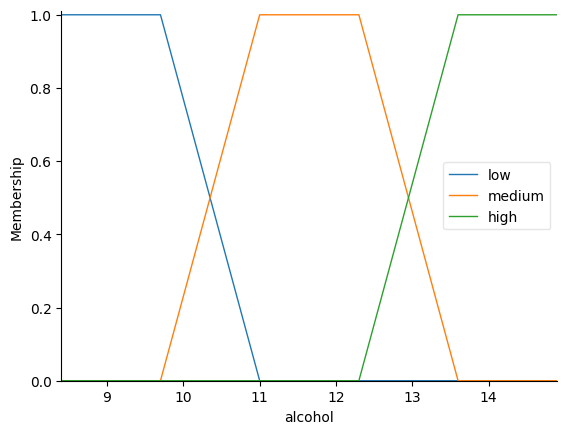

In [16]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
alcohol = ctrl.Antecedent(np.arange(X_reduced_min['alcohol'], X_reduced_max['alcohol']+0.1, 0.1), 'alcohol')

alcohol_dif = X_reduced_max['alcohol'] - X_reduced_min['alcohol']
alcohol['low'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol']+0.2*alcohol_dif,
                                               X_reduced_min['alcohol']+0.4*alcohol_dif])
alcohol['medium'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.2*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.4*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.8*alcohol_dif])
alcohol['high'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                X_reduced_min['alcohol']+0.8*alcohol_dif,
                                                X_reduced_max['alcohol'],
                                                X_reduced_max['alcohol']])

alcohol.view()

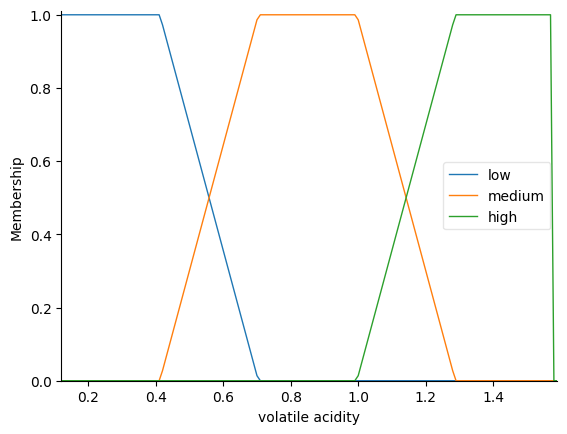

In [17]:
volatile_acidity = ctrl.Antecedent(np.arange(X_reduced_min['volatile acidity'], X_reduced_max['volatile acidity']+0.01, 0.01), 'volatile acidity')

volatile_acidity_dif = X_reduced_max['volatile acidity'] - X_reduced_min['volatile acidity']
volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                               X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif])
volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif])
volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif,
                                                X_reduced_max['volatile acidity'],
                                                X_reduced_max['volatile acidity']])

volatile_acidity.view()

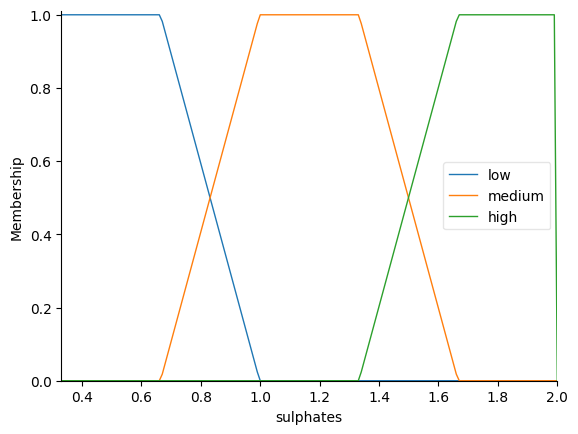

In [18]:
sulphates = ctrl.Antecedent(np.arange(X_reduced_min['sulphates'], X_reduced_max['sulphates']+0.01, 0.01), 'sulphates')

sulphates_dif = X_reduced_max['sulphates'] - X_reduced_min['sulphates']
sulphates['low'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates']+0.2*sulphates_dif,
                                               X_reduced_min['sulphates']+0.4*sulphates_dif])
sulphates['medium'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.2*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.4*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.8*sulphates_dif])
sulphates['high'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                X_reduced_min['sulphates']+0.8*sulphates_dif,
                                                X_reduced_max['sulphates'],
                                                X_reduced_max['sulphates']])

sulphates.view()

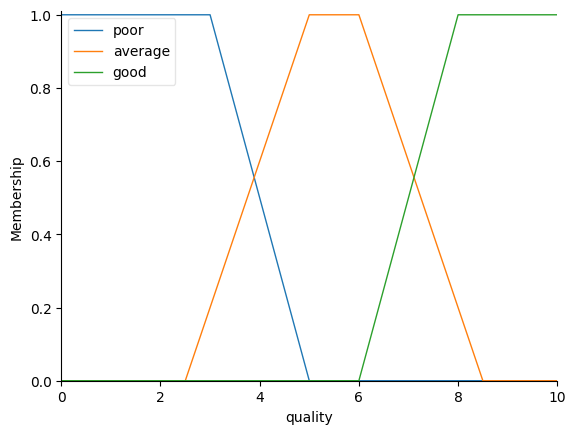

In [19]:
quality = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'quality')

quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, 3, 5])
quality['average'] = fuzz.trapmf(quality.universe, [2.5, 5, 6, 8.5])
quality['good'] = fuzz.trapmf(quality.universe, [6, 8, 10, 10])

quality.view()

In [20]:
import itertools

waga_input = {
    'alcohol': {'low': 1, 'medium': 2, 'high': 3},
    'volatile_acidity': {'low': 3, 'medium': 2, 'high': 1},
    'sulphates': {'low': 1, 'medium': 2, 'high': 3}
}

rules = []

for alc, vac, sul in itertools.product(['low', 'medium', 'high'], repeat=3):
    score = waga_input['alcohol'][alc] + waga_input['volatile_acidity'][vac] + waga_input['sulphates'][sul]

    if score <= 4:
        out_quality = 'poor'
    elif score >= 8:
        out_quality = 'good'
    else:
        out_quality = 'average'

    rule = ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out_quality])
    rules.append(rule)

control_system = ctrl.ControlSystem(rules)
model = ctrl.ControlSystemSimulation(control_system)

Model proponuje jakość:  8.4


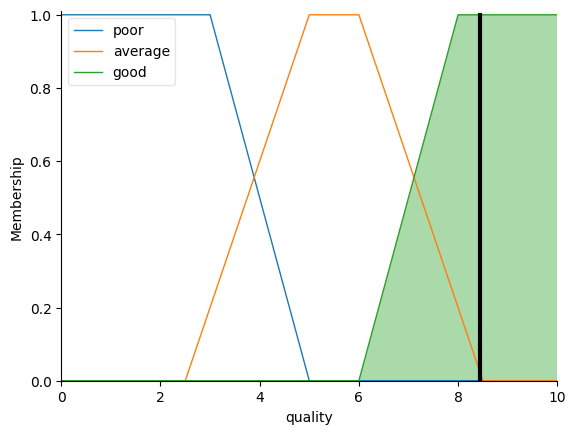

In [21]:
model.input['alcohol'] = 14.0
model.input['volatile acidity'] = 0.4
model.input['sulphates'] = 1.8

model.compute()

print('Model proponuje jakość: ', round(model.output['quality'], 1))
quality.view(sim=model)

In [22]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
import numpy as np
import itertools

def fuzzy_system_creator_trapmf(parameters):

    # p_alc = sorted(parameters[0:8])
    # p_vac = sorted(parameters[8:16])
    # p_sul = sorted(parameters[16:24])
    # p_qlt = sorted(parameters[24:32])

    # alcohol = ctrl.Antecedent(np.arange(X_reduced_min['alcohol'], X_reduced_max['alcohol']+0.1, 0.1), 'alcohol')

    # alcohol_dif = X_reduced_max['alcohol'] - X_reduced_min['alcohol']
    # alcohol['low'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol'],
    #                                               X_reduced_min['alcohol'],
    #                                               X_reduced_min['alcohol']+p_alc[0]*alcohol_dif,
    #                                               X_reduced_min['alcohol']+p_alc[1]*alcohol_dif])
    # alcohol['medium'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+p_alc[2]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[3]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[4]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[5]*alcohol_dif])
    # alcohol['high'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+p_alc[6]*alcohol_dif,
    #                                                 X_reduced_min['alcohol']+p_alc[7]*alcohol_dif,
    #                                                 X_reduced_max['alcohol'],
    #                                                 X_reduced_max['alcohol']])


    # volatile_acidity = ctrl.Antecedent(np.arange(X_reduced_min['volatile acidity'], X_reduced_max['volatile acidity']+0.01, 0.01), 'volatile acidity')

    # volatile_acidity_dif = X_reduced_max['volatile acidity'] - X_reduced_min['volatile acidity']
    # volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity'],
    #                                               X_reduced_min['volatile acidity'],
    #                                               X_reduced_min['volatile acidity']+p_vac[0]*volatile_acidity_dif,
    #                                               X_reduced_min['volatile acidity']+p_vac[1]*volatile_acidity_dif])
    # volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+p_vac[2]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[3]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[4]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[5]*volatile_acidity_dif])
    # volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+p_vac[6]*volatile_acidity_dif,
    #                                                 X_reduced_min['volatile acidity']+p_vac[7]*volatile_acidity_dif,
    #                                                 X_reduced_max['volatile acidity'],
    #                                                 X_reduced_max['volatile acidity']])

    # sulphates = ctrl.Antecedent(np.arange(X_reduced_min['sulphates'], X_reduced_max['sulphates']+0.01, 0.01), 'sulphates')

    # sulphates_dif = X_reduced_max['sulphates'] - X_reduced_min['sulphates']
    # sulphates['low'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates'],
    #                                               X_reduced_min['sulphates'],
    #                                               X_reduced_min['sulphates']+p_sul[0]*sulphates_dif,
    #                                               X_reduced_min['sulphates']+p_sul[1]*sulphates_dif])
    # sulphates['medium'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+p_sul[2]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[3]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[4]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[5]*sulphates_dif])
    # sulphates['high'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+p_sul[6]*sulphates_dif,
    #                                                 X_reduced_min['sulphates']+p_sul[7]*sulphates_dif,
    #                                                 X_reduced_max['sulphates'],
    #                                                 X_reduced_max['sulphates']])

    # quality = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'quality')

    # quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, p_qlt[0], p_qlt[1]])
    # quality['average'] = fuzz.trapmf(quality.universe, [p_qlt[2], p_qlt[3], p_qlt[4], p_qlt[5]])
    # quality['good'] = fuzz.trapmf(quality.universe, [p_qlt[6], p_qlt[7], 10, 10])

    alcohol = ctrl.Antecedent(np.linspace(bounds['alc'][0], bounds['alc'][1],100), 'alcohol')
    volatile_acidity = ctrl.Antecedent(np.linspace(bounds['vac'][0], bounds['vac'][1],100), 'volatile acidity')
    sulphates = ctrl.Antecedent(np.linspace(bounds['sul'][0], bounds['sul'][1],100), 'sulphates')
    quality = ctrl.Consequent(np.linspace(bounds['qlt'][0], bounds['qlt'][1],100), 'quality')

    p = np.sort(parameters[0:4])
    alcohol['low'] = fuzz.trapmf(alcohol.universe, [
        bounds['alc'][0],
        bounds['alc'][0],
        p[0],
        p[1]
    ])
    alcohol['medium'] = fuzz.trapmf(alcohol.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    alcohol['high'] = fuzz.trapmf(alcohol.universe, [
        p[2],
        p[3],
        bounds['alc'][1],
        bounds['alc'][1]
    ])

    p = np.sort(parameters[4:8])
    volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [
        bounds['vac'][0],
        bounds['vac'][0],
        p[0],
        p[1]
    ])
    volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [
        p[2],
        p[3],
        bounds['vac'][1],
        bounds['vac'][1]
    ])

    p = np.sort(parameters[8:12])
    sulphates['low'] = fuzz.trapmf(sulphates.universe, [
        bounds['sul'][0],
        bounds['sul'][0],
        p[0],
        p[1]
    ])
    sulphates['medium'] = fuzz.trapmf(sulphates.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    sulphates['high'] = fuzz.trapmf(sulphates.universe, [
        p[2],
        p[3],
        bounds['sul'][1],
        bounds['sul'][1]
    ])

    p = np.sort(parameters[12:16])
    quality['poor'] = fuzz.trapmf(quality.universe, [
        bounds['qlt'][0],
        bounds['qlt'][0],
        p[0],
        p[1]
    ])
    quality['average'] = fuzz.trapmf(quality.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    quality['good'] = fuzz.trapmf(quality.universe, [
        p[2],
        p[3],
        bounds['qlt'][1],
        bounds['qlt'][1]
    ])

    waga_input = {
    'alcohol': {'low': 1, 'medium': 2, 'high': 3},
    'volatile_acidity': {'low': 3, 'medium': 2, 'high': 1},
    'sulphates': {'low': 1, 'medium': 2, 'high': 3}
    }

    rules = []

    for alc, vac, sul in itertools.product(['low', 'medium', 'high'], repeat=3):
        score = waga_input['alcohol'][alc] + waga_input['volatile_acidity'][vac] + waga_input['sulphates'][sul]

        if score <= 4:
            out_quality = 'poor'
        elif score >= 8:
            out_quality = 'good'
        else:
            out_quality = 'average'

        rule = ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out_quality])
        rules.append(rule)

    control_system = ctrl.ControlSystem(rules)
    model = ctrl.ControlSystemSimulation(control_system)

    return model, alcohol, volatile_acidity, sulphates, quality

### Validating `fuzzy_system_creator_trapmf`

Validating fuzzy_system_creator_trapmf...
Fuzzy system (trapmf) created successfully.


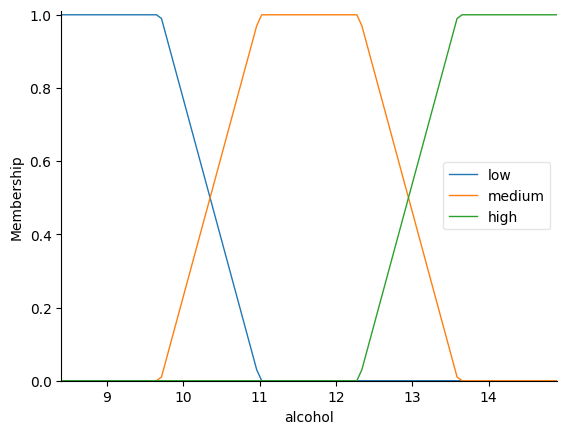

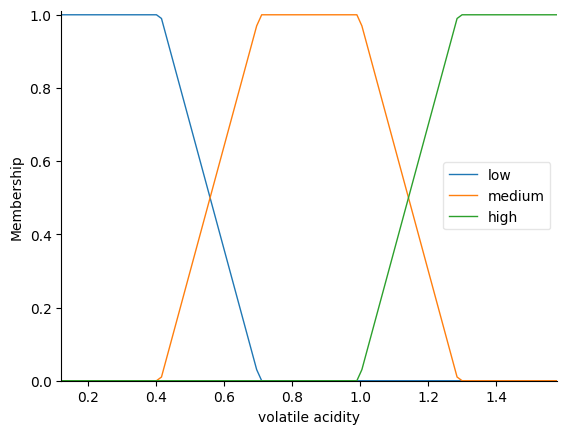

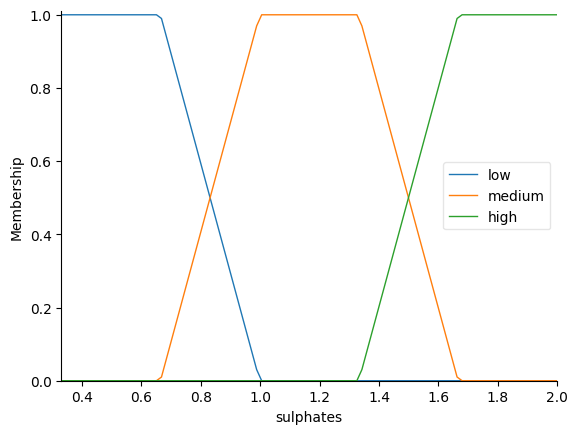

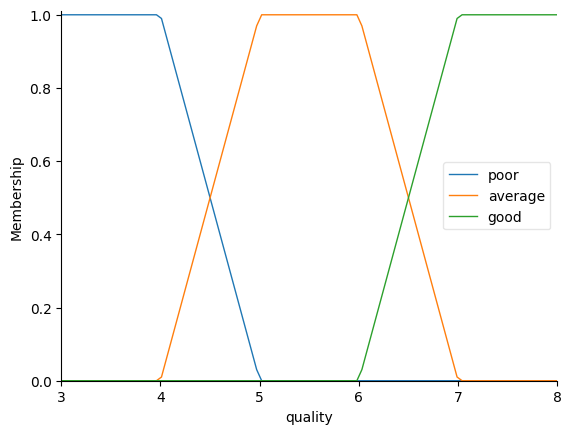

In [23]:
print('Validating fuzzy_system_creator_trapmf...')

# Dummy parameters for trapezoidal membership functions (4 * 4 = 16 parameters)
# For simplicity, let's distribute them evenly within the bounds for each variable.
# alcohol: 4 parameters, volatile_acidity: 4, sulphates: 4, quality: 4
dummy_params_trapmf = np.array([
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.1,  # alc low_a
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.2,  # alc low_b
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.3,  # alc med_a
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.4,  # alc med_b
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.6,  # alc med_c
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.7,  # alc med_d
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.8,  # alc high_c
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.9,  # alc high_d

    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.1,  # vac low_a
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.2,  # vac low_b
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.3,  # vac med_a
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.4,  # vac med_b
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.6,  # vac med_c
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.7,  # vac med_d
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.8,  # vac high_c
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.9,  # vac high_d

    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.1,  # sul low_a
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.2,  # sul low_b
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.3,  # sul med_a
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.4,  # sul med_b
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.6,  # sul med_c
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.7,  # sul med_d
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.8,  # sul high_c
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.9,  # sul high_d

    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.1,  # qlt poor_a
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.3,  # qlt poor_b
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.4,  # qlt avg_a
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.6,  # qlt avg_b
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.7,  # qlt avg_c
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.9,  # qlt avg_d
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.8,  # qlt good_c
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.9  # qlt good_d
])

# Ensure the array has the correct shape for the function (16 parameters if it is 4 per each)
# Let's re-evaluate the expected number of parameters for fuzzy_system_creator_trapmf based on the function's internal parameter slicing.
# The function has 'p = np.sort(parameters[0:4])' for alcohol, and similar for others.
# This means 4 parameters per variable. Total 4 variables (alcohol, volatile acidity, sulphates, quality) = 16 parameters.

# Let's use a simpler dummy_params_trapmf with 16 elements, ensuring they are sorted within their respective groups if needed by the function.

dummy_params_trapmf_corrected = np.array([
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.2, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.4, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.6, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.8, # alcohol
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.2, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.4, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.6, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.8, # volatile acidity
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.2, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.4, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.6, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.8, # sulphates
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.2, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.4, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.6, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.8  # quality
])

sys_trapmf, alcohol_trapmf, volatile_acidity_trapmf, sulphates_trapmf, quality_trapmf = fuzzy_system_creator_trapmf(dummy_params_trapmf_corrected)

print("Fuzzy system (trapmf) created successfully.")

alcohol_trapmf.view()
volatile_acidity_trapmf.view()
sulphates_trapmf.view()
quality_trapmf.view()

In [24]:
import pandas as pd
import skfuzzy as fuzz
from sklearn.metrics import mean_squared_error
import pyswarms as ps
import requests
import io

# ---------------------------------------------------------
# 3. OPTYMALIZACJA PSO
# ---------------------------------------------------------
def fitness_function(swarm_params):
    n_particles = swarm_params.shape[0]
    results = []

    # Dla przyspieszenia obliczeń w PSO używamy podzbioru danych treningowych
    X_sub_np = X_train.values # Convert X_sub to a numpy array for robust iteration
    y_sub_flat = y_train.values.flatten() # Convert y_sub to a 1D numpy array

    default_prediction = y_sub_flat.mean()

    for i in range(n_particles):
        try:
            # Correctly unpack the tuple returned by fuzzy_system_creator_trapmf
            sim_model, _, _, _, _ = fuzzy_system_creator_trapmf(swarm_params[i])

            preds_particle = np.full(len(X_sub_np), default_prediction) # Initialize predictions for current particle

            for j, val in enumerate(X_sub_np):
                try:
                    sim_model.input['alcohol'] = val[0]
                    sim_model.input['volatile acidity'] = val[1]
                    sim_model.input['sulphates'] = val[2]
                    sim_model.compute()
                    preds_particle[j] = sim_model.output['quality']
                except:
                    # If computation fails for a specific input, the default_prediction
                    # for this index in 'preds_particle' will remain.
                    pass

            # Both y_sub_flat and preds_particle are now 1D numpy arrays of the same length
            results.append(mean_squared_error(y_sub_flat, preds_particle))
        except Exception as e:
            # This outer except block catches errors during fuzzy system creation itself
            # or other unexpected issues before prediction calculation.
            results.append(100.0) # Penalty for a failed fuzzy system

    return np.array(results)

In [25]:
def evaluate(model, X, y):
    # Initialize predictions with a default value (e.g., mean of y_true)
    # This ensures `preds` always has the same length as `y`.
    default_prediction = np.mean(y)
    preds = np.full(len(X), default_prediction)

    for i, val in enumerate(X.values):
        try:
            model.input['alcohol'] = val[0]
            model.input['volatile acidity'] = val[1]
            model.input['sulphates'] = val[2]
            model.compute()
            preds[i] = model.output['quality']
        except:
            # If computation fails for this specific input, the default_prediction
            # for this index in 'preds' will remain.
            pass # The default value in preds will be used for this entry.
    return mean_squared_error(y, preds)

Creating initial fuzzy system using genfis_trapmf_matlab_like...
Initial fuzzy system created successfully using genfis_trapmf_matlab_like.


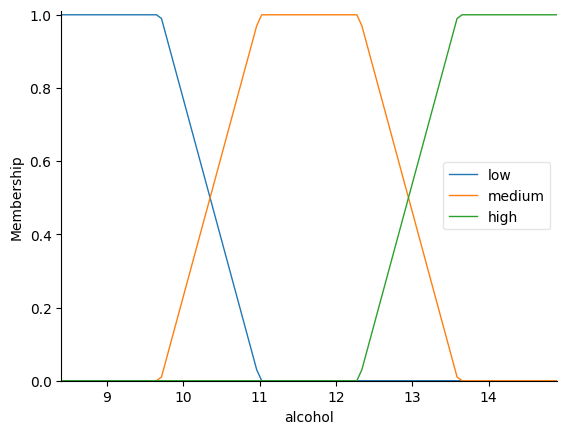

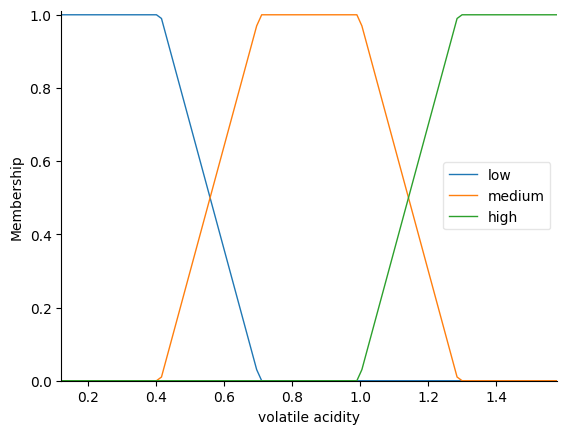

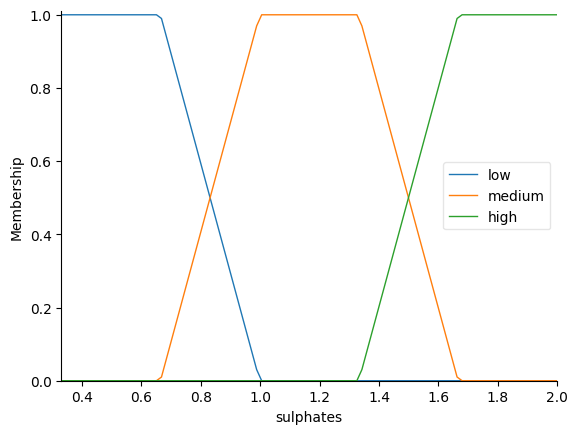

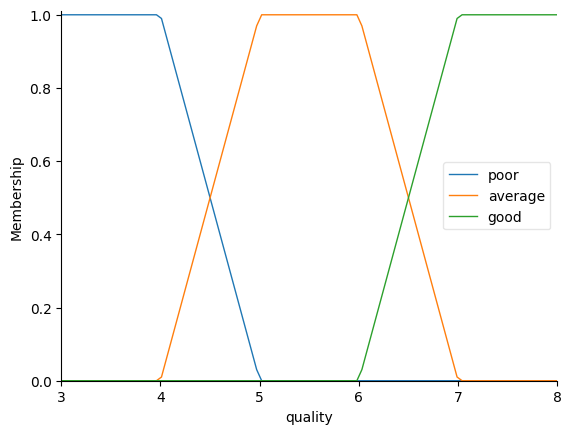

In [26]:
import numpy as np

def generate_initial_trapmf_params(bounds):
    """
    Generates initial parameters for trapezoidal membership functions.
    These parameters are structured for use with fuzzy_system_creator_trapmf,
    ensuring the 'a <= b <= c <= d' condition for trapezoids.

    Args:
        bounds (dict): A dictionary containing min/max bounds for each variable
                       ('alc', 'vac', 'sul', 'qlt').

    Returns:
        np.array: A 1D numpy array of 16 parameters (4 for each of 4 variables).
    """
    all_params = []
    # Order of variables as expected by fuzzy_system_creator_trapmf
    variable_keys = ['alc', 'vac', 'sul', 'qlt']

    # These points define the 'shoulders' and 'feet' of the trapezoidal MFs.
    # The fuzzy_system_creator_trapmf function uses these points to define:
    # 'low':    [min, min, p[0], p[1]]
    # 'medium': [p[0], p[1], p[2], p[3]]
    # 'high':   [p[2], p[3], max, max]
    # We ensure p[0] <= p[1] <= p[2] <= p[3] and they are within [min, max].

    # Using quartiles of the range for a reasonable initial spread.
    # These percentages can be adjusted for different initial distributions.
    relative_points = [0.20, 0.40, 0.60, 0.80]

    for key in variable_keys:
        min_val, max_val = bounds[key]
        value_range = max_val - min_val

        # Calculate the 4 points for the current variable
        p0 = min_val + (value_range * relative_points[0])
        p1 = min_val + (value_range * relative_points[1])
        p2 = min_val + (value_range * relative_points[2])
        p3 = min_val + (value_range * relative_points[3])

        current_var_params = [p0, p1, p2, p3]
        all_params.extend(current_var_params)

    return np.array(all_params)

def genfis_trapmf_matlab_like(bounds):
    """
    Generates an initial fuzzy inference system (FIS) using trapezoidal membership functions,
    similar to how 'genfis' might initialize a system in MATLAB for grid partitioning.

    Args:
        bounds (dict): A dictionary containing min/max bounds for each variable
                       ('alc', 'vac', 'sul', 'qlt').

    Returns:
        tuple: A tuple containing the control system simulation object, and the
               antecedent/consequent fuzzy variables (alcohol, volatile_acidity,
               sulphates, quality).
    """
    initial_params = generate_initial_trapmf_params(bounds)
    return fuzzy_system_creator_trapmf(initial_params)

# Now, use this function to create the model
print('Creating initial fuzzy system using genfis_trapmf_matlab_like...')
model_genfis, alc_genfis, vac_genfis, sul_genfis, qlt_genfis = genfis_trapmf_matlab_like(bounds)
print('Initial fuzzy system created successfully using genfis_trapmf_matlab_like.')

# Optionally, view the generated membership functions
alc_genfis.view()
vac_genfis.view()
sul_genfis.view()
qlt_genfis.view()

In [27]:
import pyswarms as ps
import matplotlib.pyplot as plt

def run_pso_and_get_history(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test):
    """
    Runs PSO optimization, collects cost history, and evaluates the best model on the test set.

    Args:
        n_particles (int): Number of particles in the swarm.
        dimensions (int): Number of dimensions (parameters) to optimize.
        iters (int): Number of iterations for the optimizer.
        options (dict): Dictionary of PSO options (c1, c2, w).
        pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
        fitness_function (function): The fitness function to optimize.
        X_test (pd.DataFrame): Test feature data.
        y_test (pd.DataFrame): Test target data.

    Returns:
        tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
    """
    optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    # Evaluate the best found position on the test set
    # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
    sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf(best_pos)
    mse_on_test_set = evaluate(sim_model_best_pso, X_test, y_test)

    return best_cost, best_pos, optimizer.cost_history, mse_on_test_set


### PSO Optimization: `c1 = c2`

Let's run PSO with `c1` and `c2` set to equal values (e.g., `c1=0.7`, `c2=0.7`). We'll track the MSE history and visualize it.

2026-06-01 21:34:43,925 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.7, 'c2': 0.7, 'w': 0.9}


Running PSO with c1=c2 (30 iterations)...


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.47
2026-06-01 23:40:16,888 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.47013798324801503, best pos: [10.38845255 10.92448457 11.80461114 10.12357733  1.10544969  1.12429159
  1.36868114  1.55582272  0.71642576  0.48755389  0.66167571  0.88583896
  4.48488052  7.57408339  4.54839127  3.75415358]


Final Best Cost (c1=c2): 0.4701
MSE on Test Set (c1=c2): 0.5205


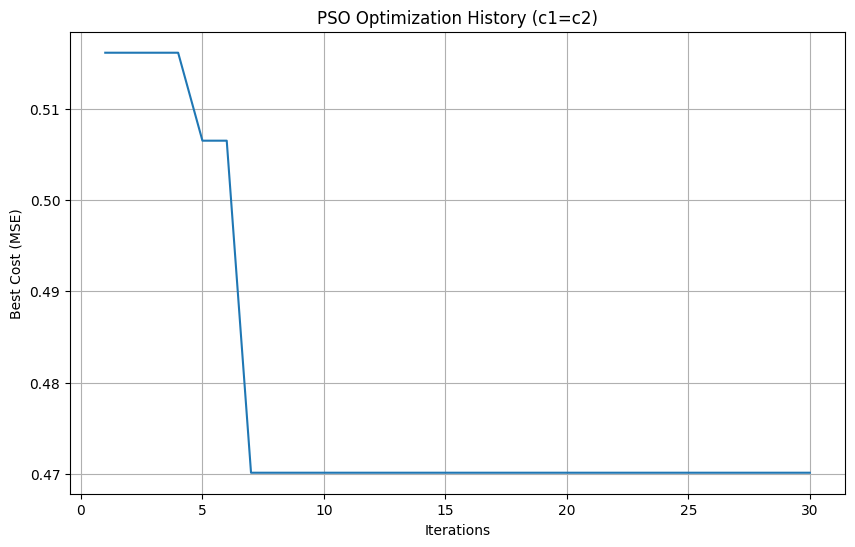

In [22]:
# Zakresy poszukiwań dla PSO (znormalizowane do zakresów zmiennych)
max_bound = np.array([bounds['alc'][1]]*4 + [bounds['vac'][1]]*4 + [bounds['sul'][1]]*4 + [bounds['qlt'][1]]*4)
min_bound = np.array([bounds['alc'][0]]*4 + [bounds['vac'][0]]*4 + [bounds['sul'][0]]*4 + [bounds['qlt'][0]]*4) # Corrected bounds['sul'][1] to bounds['sul'][0]
pso_bounds = (min_bound, max_bound)

# Configuration for c1 = c2
n_particles = 20
dimensions = 16 # Number of parameters for trapezoidal MFs
iters = 30 # Using the max of range(2,7,2) as requested
options_c1_eq_c2 = {'c1': 0.7, 'c2': 0.7, 'w': 0.9}

print("Running PSO with c1=c2 ({} iterations)...".format(iters))
best_cost_eq, best_pos_eq, cost_history_eq, mse_pso_eq = run_pso_and_get_history(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_eq_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test
)

print(f"Final Best Cost (c1=c2): {best_cost_eq:.4f}")
print(f"MSE on Test Set (c1=c2): {mse_pso_eq:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_eq)
plt.title('PSO Optimization History (c1=c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


### PSO Optimization: `c1 < c2`

Next, let's test a configuration where `c1` is less than `c2` (e.g., `c1=0.5`, `c2=0.8`).

Running PSO with c1<c2 (30 iterations)...


2026-06-01 23:40:29,813 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.8, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.478
2026-06-02 01:45:44,106 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4776616176776267, best pos: [ 9.1757747  11.87074669 11.37273272 11.61465471  1.41203415  0.23480775
  1.32719176  1.44430018  0.96824252  1.25441058  0.41275735  0.73141258
  4.27133741  4.38838865  7.47658623  5.62060154]


Final Best Cost (c1<c2): 0.4777
MSE on Test Set (c1<c2): 0.5442


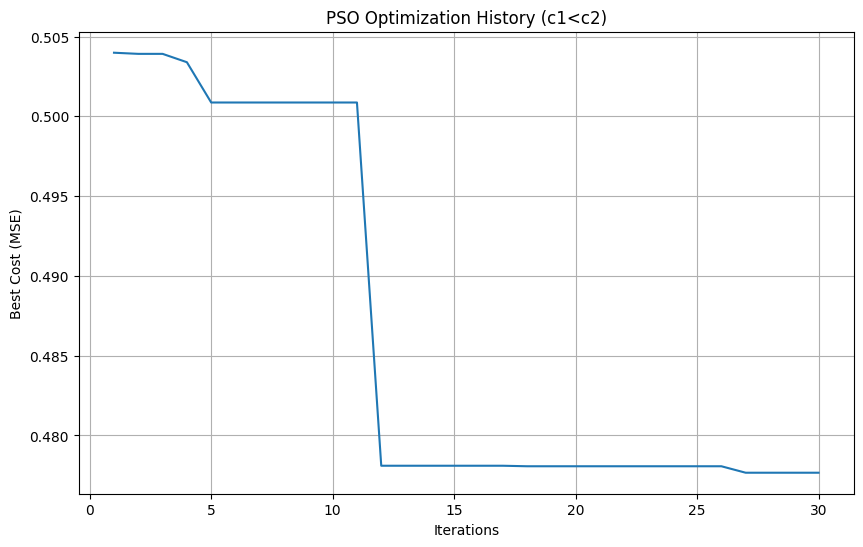

In [23]:
# Configuration for c1 < c2
options_c1_lt_c2 = {'c1': 0.5, 'c2': 0.8, 'w': 0.9}

print("Running PSO with c1<c2 ({} iterations)...".format(iters))
best_cost_lt, best_pos_lt, cost_history_lt, mse_pso_lt = run_pso_and_get_history(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_lt_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test
)

print(f"Final Best Cost (c1<c2): {best_cost_lt:.4f}")
print(f"MSE on Test Set (c1<c2): {mse_pso_lt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_lt)
plt.title('PSO Optimization History (c1<c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


### PSO Optimization: `c1 > c2`

Finally, let's explore a scenario where `c1` is greater than `c2` (e.g., `c1=0.8`, `c2=0.5`).

2026-06-02 01:45:56,790 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.8, 'c2': 0.5, 'w': 0.9}


Running PSO with c1>c2 (30 iterations)...


pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.497
2026-06-02 03:51:24,798 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.49657643462953377, best pos: [11.27484827  9.82990562 12.8690003  10.1991552   1.33808569  0.41984762
  0.53478258  0.38796557  1.85744012  0.60440081  0.36244615  0.88701719
  5.37961488  7.83624661  4.12711888  4.74371373]


Final Best Cost (c1>c2): 0.4966
MSE on Test Set (c1>c2): 0.5561


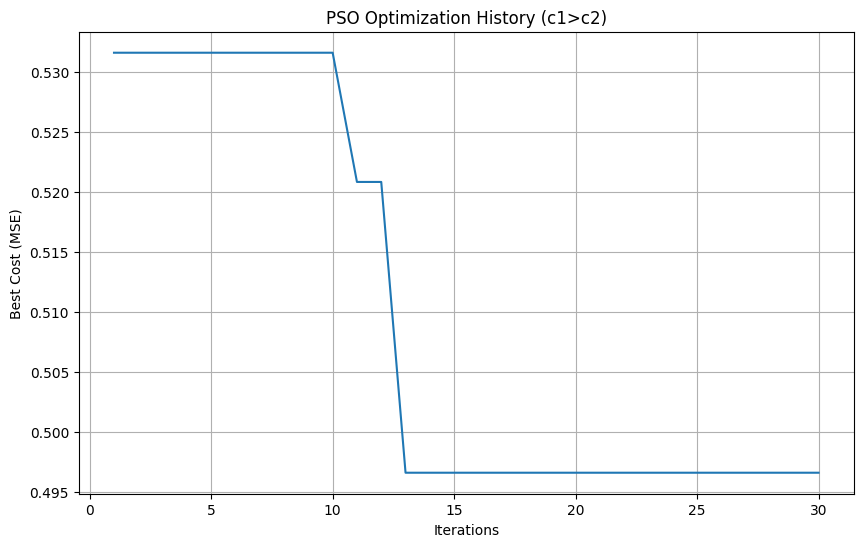

In [24]:
# Configuration for c1 > c2
options_c1_gt_c2 = {'c1': 0.8, 'c2': 0.5, 'w': 0.9}

print("Running PSO with c1>c2 ({} iterations)...".format(iters))
best_cost_gt, best_pos_gt, cost_history_gt, mse_pso_gt = run_pso_and_get_history(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_gt_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test
)

print(f"Final Best Cost (c1>c2): {best_cost_gt:.4f}")
print(f"MSE on Test Set (c1>c2): {mse_pso_gt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gt)
plt.title('PSO Optimization History (c1>c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


### Comparison of All Models

Now, let's visualize the performance of the baseline `genfis` model against all the PSO-optimized models on the test set.

In [28]:
print("PORÓWNANIE BŁĘDU MSE (NA ZBIORZE TESTOWYM)")
print("="*30)

#testy się przerwały, więc manualnie wstawione parametry

best_pos_eq=[10.38845255, 10.92448457, 11.80461114, 10.12357733,  1.10544969,  1.12429159,
  1.36868114, 1.55582272,  0.71642576,  0.48755389,  0.66167571,  0.88583896,
  4.48488052,  7.57408339,  4.54839127,  3.75415358]
best_pos_lt= [ 9.1757747,  11.87074669, 11.37273272, 11.61465471,  1.41203415,  0.23480775,
  1.32719176,  1.44430018,  0.96824252,  1.25441058,  0.41275735,  0.73141258,
  4.27133741,  4.38838865,  7.47658623,  5.62060154]
best_pos_gt = [11.27484827, 9.82990562, 12.8690003, 10.1991552, 1.33808569, 0.41984762,
  0.53478258,  0.38796557,  1.85744012,  0.60440081,  0.36244615,  0.88701719,
  5.37961488,  7.83624661,  4.12711888,  4.74371373]

mse_pso = evaluate(fuzzy_system_creator_trapmf(best_pos_gt), X_test, y_test)
mse_genfis = evaluate(model_genfis, X_test, y_test)
print(f"Model FL + Optymalizacja PSO:  {mse_pso:.4f}")
print(f"Model FL 'genfis' (baseline):  {mse_genfis:.4f}")
print("-" * 30)
if mse_pso < mse_genfis:
    print("WYNIK: PSO poprawiło parametry systemu rozmytego względem podziału automatycznego.")
else:
    print("WYNIK: Model automatyczny okazał się wystarczający (PSO wymaga więcej iteracji).")

PORÓWNANIE BŁĘDU MSE (NA ZBIORZE TESTOWYM)
Model FL + Optymalizacja PSO:  0.7046
Model FL 'genfis' (baseline):  0.8644
------------------------------
WYNIK: PSO poprawiło parametry systemu rozmytego względem podziału automatycznego.


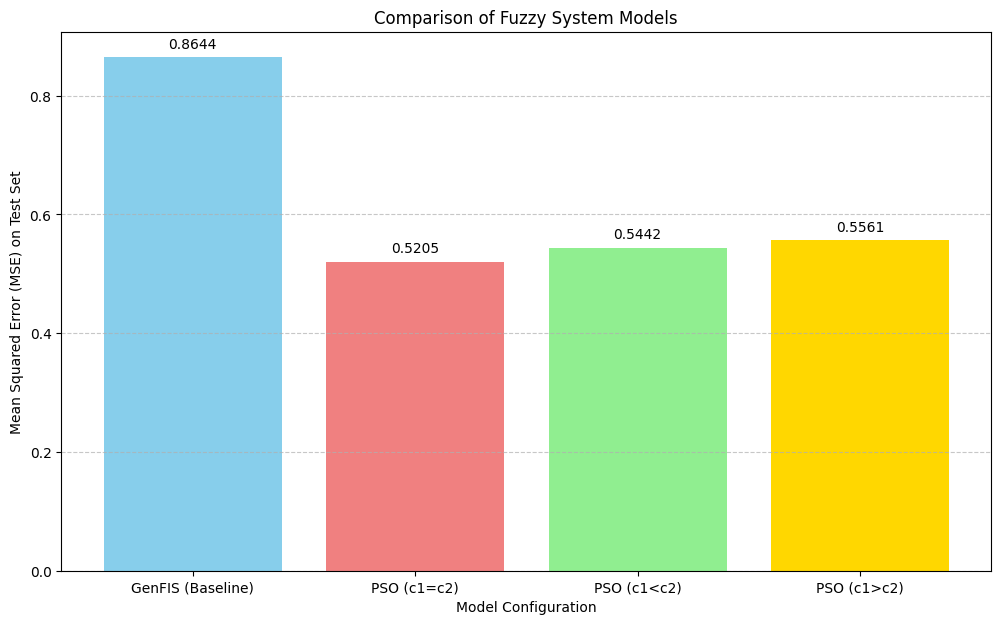

In [31]:
# Data for comparison
model_names = [
    "GenFIS (Baseline)",
    "PSO (c1=c2)",
    "PSO (c1<c2)",
    "PSO (c1>c2)"
]

#testy się przerwały, więc manualnie wstawione parametry
mse_pso_gt = 0.5561
mse_pso_eq = 0.5205
mse_pso_lt = 0.5442

mse_values = [
    mse_genfis, # This is already calculated from previous cells
    mse_pso_eq,
    mse_pso_lt,
    mse_pso_gt
]

plt.figure(figsize=(12, 7))
plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Model Configuration')
plt.ylabel('Mean Squared Error (MSE) on Test Set')
plt.title('Comparison of Fuzzy System Models')
plt.ylim(bottom=0) # Ensure y-axis starts from 0

for i, mse in enumerate(mse_values):
    plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
